# Риск-менеджмент крипто-портфеля: исследование

*Лабораторный журнал к модулю риск-менеджмента высокоскоростной торговой системы.*

Что мы здесь делаем. У нас есть проект — HFT-система с глубоким обучением, которая
торгует криптой и адаптирует свои стратегии. У такой системы должен быть «второй контур» —
**риск-менеджмент**, который не пускает её в дикие позиции, считает реальные убытки и
вовремя кричит «стоп». Этот ноутбук — рабочая тетрадь, в которой мы аккуратно проходим
все шаги построения такого контура: от сбора данных и проверки гипотез о доходностях до
EVT-хвостов, стресс-тестов и адаптивного сайзинга. Производственный код вынесен в пакет
`crypto_risk`, а здесь мы его используем и **смотрим** на результаты.

Сразу два технических замечания. Во-первых, данные — реальные, с 2015 года, собираются
мультиисточниковым парсером (CryptoCompare → Yahoo → CoinGecko → Binance). Во-вторых,
крипта торгуется 24/7, поэтому в году у нас **365** дней, а не 252, и это везде учтено.


## 0. Подготовка

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('.'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (13, 4.5),
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 90,
})
sns.set_palette('tab10')

import crypto_risk as cr
from crypto_risk import RiskEngine, RiskConfig
from crypto_risk.data import (MultiSourceCryptoLoader, TOP10_POPULAR,
                              CryptoCompareSource, YahooSource, BinanceCcxtSource,
                              CryptoDataLoader, fetch_order_book_snapshot)
from crypto_risk import volatility as vol, var_es as ve, backtesting as bt
from crypto_risk import portfolio as pf, liquidity as liq, dependence as dep
from crypto_risk import controls as ctl, evt, covariance as cvm, stress as stm

np.random.seed(cr.config.RANDOM_SEED)
print(f"crypto_risk v{cr.__version__}  |  TOP-10 = {', '.join(TOP10_POPULAR)}")

crypto_risk v1.0.0  |  TOP-10 = BTC, ETH, BNB, XRP, SOL, ADA, DOGE, TRX, LINK, LTC


## 1. Сбор данных: длинная история и фолбэк-цепочка

Главная боль крипто-данных в том, что **ни один бесплатный источник не даёт всю картину**.
Binance, на котором сейчас удобнее всего тянуть данные через `ccxt`, заработал только в
2017 году — никакой истории с 2015 у него нет. CoinGecko на бесплатном тарифе режет
дневные данные глубже 1 года. Yahoo берёт от CoinMarketCap, и там тоже не всё гладко.
Единственный «честный» бесплатный источник с реально длинной историей — **CryptoCompare**:
его агрегатор отдаёт дневные котировки с 2010 года в одном вызове.

Поэтому парсер сделан как **цепочка источников**: пробует CryptoCompare, если не вышло —
Yahoo, потом CoinGecko, потом Binance, и в самом конце — синтетический генератор как
оффлайн-фолбэк. Дополнительно — *дозаполнение пропусков* из следующих источников: если
основной отдал ряд с дырками, мы их закрываем тем, что есть у других.

Покажу всё в действии. Сначала маленькая демонстрация — что отдаёт каждый источник для BTC.


In [2]:
# Заглянем по очереди в каждый источник для BTC 2015-2025
for src in [CryptoCompareSource(), YahooSource(), BinanceCcxtSource()]:
    try:
        s = src.fetch_close('BTC', '2015-01-01', '2025-01-01')
        if not s.empty:
            print(f"  {src.name:14}: {len(s):4} дней,  {s.index.min().date()} -> {s.index.max().date()},"
                  f"  цена0={s.iloc[0]:.0f}  ценаN={s.iloc[-1]:.0f}")
        else:
            print(f"  {src.name:14}: пусто")
    except Exception as e:
        print(f"  {src.name:14}: ошибка {type(e).__name__}")

  cryptocompare : 3654 дней,  2015-01-01 -> 2025-01-01,  цена0=315  ценаN=94393


  yahoo         : 3654 дней,  2015-01-01 -> 2025-01-01,  цена0=314  ценаN=94420


  binance       : 2695 дней,  2017-08-17 -> 2025-01-01,  цена0=4285  ценаN=94592


CryptoCompare даёт нам полный кусок с самой первой свечи 2015 года — в районе $300 за BTC.
Yahoo стартует ровно с 2015-01-01, Binance — только с 2017. Этого достаточно, чтобы
парсер был устойчив: если CryptoCompare вдруг ляжет или ограничит трафик, мы
автоматически перейдём на Yahoo.

Теперь тянем всю десятку популярных монет.

In [3]:
loader = MultiSourceCryptoLoader(universe=TOP10_POPULAR, mode='auto')
prices_full = loader.load_close_panel('2015-01-01', '2025-01-01')
print(f"Источник: {loader.source_used}")
print(f"Период:   {prices_full.index.min().date()} -> {prices_full.index.max().date()}")
print(f"Размер:   {prices_full.shape[0]} дней × {prices_full.shape[1]} монет")
prices_full.tail(3).round(3)

Источник: cache:multi_10assets_2015-01-01_2025-01-01.csv
Период:   2015-01-01 -> 2025-01-01
Размер:   3654 дней × 10 монет


,BTC,ETH,BNB,XRP,SOL,ADA,DOGE,TRX,LINK,LTC
date,,,,,,,,,,
2024-12-30 00:00:00+00:00,92646.21,3356.45,704.11,2.055,191.04,0.860,0.313,0.253,20.55,99.25
2024-12-31 00:00:00+00:00,93391.98,3331.15,700.91,2.080,188.87,0.844,0.315,0.255,19.97,103.07
2025-01-01 00:00:00+00:00,94392.51,3353.28,706.43,2.328,193.85,0.920,0.324,0.256,21.69,105.03


In [4]:
# Когда родилась каждая монета (по данным)
inception = prices_full.apply(lambda c: c.first_valid_index())
print("Даты появления в наших данных:")
for c, d in inception.items():
    print(f"  {c:5} -> {d.date()}")

Даты появления в наших данных:
  BTC   -> 2015-01-01
  ETH   -> 2015-08-07
  BNB   -> 2017-08-14
  XRP   -> 2015-01-29
  SOL   -> 2020-04-10
  ADA   -> 2017-10-01
  DOGE  -> 2015-01-01
  TRX   -> 2017-09-04
  LINK  -> 2017-09-21
  LTC   -> 2015-01-01


Видно, что половина монет существует с 2015, а **SOL** появился только в апреле 2020. Это
важно: если для портфельной аналитики нам нужны *все* 10 одновременно, общий промежуток
начинается с 2020-04. По отдельным же монетам мы можем смотреть всё, что у них есть.

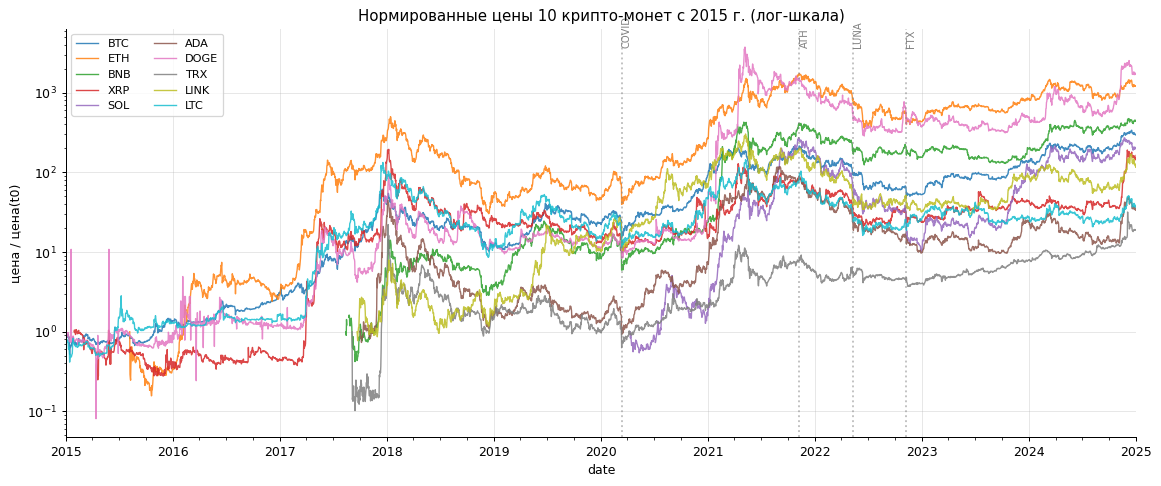

In [5]:
# Нормированные лог-цены — все 10 на одном графике
norm = prices_full.dropna(how='all').apply(lambda c: c / c.dropna().iloc[0])
fig, ax = plt.subplots(figsize=(13, 5.5))
norm.plot(ax=ax, logy=True, lw=1.1, alpha=0.85)
ax.set_title("Нормированные цены 10 крипто-монет с 2015 г. (лог-шкала)")
ax.set_ylabel("цена / цена(t0)"); ax.legend(loc='upper left', ncol=2, fontsize=9)
ax.axvline(pd.Timestamp('2020-03-12', tz='UTC'), c='gray', ls=':', alpha=0.5)
ax.axvline(pd.Timestamp('2021-11-09', tz='UTC'), c='gray', ls=':', alpha=0.5)
ax.axvline(pd.Timestamp('2022-05-12', tz='UTC'), c='gray', ls=':', alpha=0.5)
ax.axvline(pd.Timestamp('2022-11-08', tz='UTC'), c='gray', ls=':', alpha=0.5)
ax.text(pd.Timestamp('2020-03-12', tz='UTC'), ax.get_ylim()[1]*0.6, 'COVID',
        rotation=90, fontsize=8, color='gray')
ax.text(pd.Timestamp('2021-11-09', tz='UTC'), ax.get_ylim()[1]*0.6, 'ATH',
        rotation=90, fontsize=8, color='gray')
ax.text(pd.Timestamp('2022-05-12', tz='UTC'), ax.get_ylim()[1]*0.6, 'LUNA',
        rotation=90, fontsize=8, color='gray')
ax.text(pd.Timestamp('2022-11-08', tz='UTC'), ax.get_ylim()[1]*0.6, 'FTX',
        rotation=90, fontsize=8, color='gray')
plt.tight_layout(); plt.show()

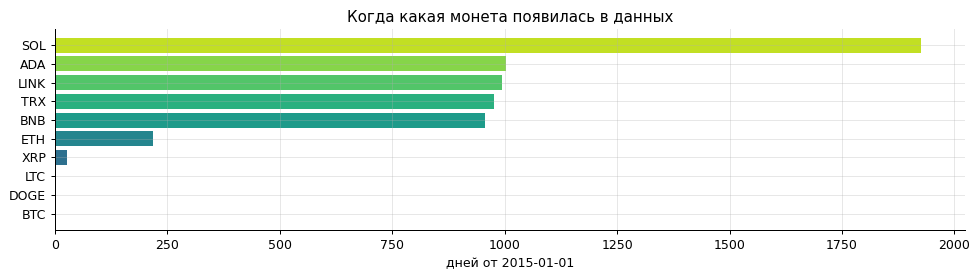

In [6]:
# Бар-чарт дат «рождения» — наглядно показывает разные стартовые точки
fig, ax = plt.subplots(figsize=(11, 3.2))
days_from_2015 = [(d - pd.Timestamp('2015-01-01', tz='UTC')).days for d in inception]
order = np.argsort(days_from_2015)
coins = inception.index.tolist()
ax.barh([coins[i] for i in order], [days_from_2015[i] for i in order],
        color=sns.color_palette('viridis', len(order)))
ax.set_xlabel("дней от 2015-01-01"); ax.set_title("Когда какая монета появилась в данных")
plt.tight_layout(); plt.show()

## 2. Доходности: первое знакомство

Дальше работаем с лог-доходностями $r_t = \ln(P_t/P_{t-1})$. Они аддитивны во времени и
гораздо ближе к стационарности, чем сами цены.

In [7]:
rets_full = vol.log_returns(prices_full)
rets_common = rets_full.dropna()   # окно, где все 10 монет есть
print(f"Полная история (NaN допустимы): {rets_full.shape}")
print(f"Общее окно (все 10 одновременно): {rets_common.shape}, "
      f"с {rets_common.index.min().date()} по {rets_common.index.max().date()}")

Полная история (NaN допустимы): (1727, 10)
Общее окно (все 10 одновременно): (1727, 10), с 2020-04-11 по 2025-01-01


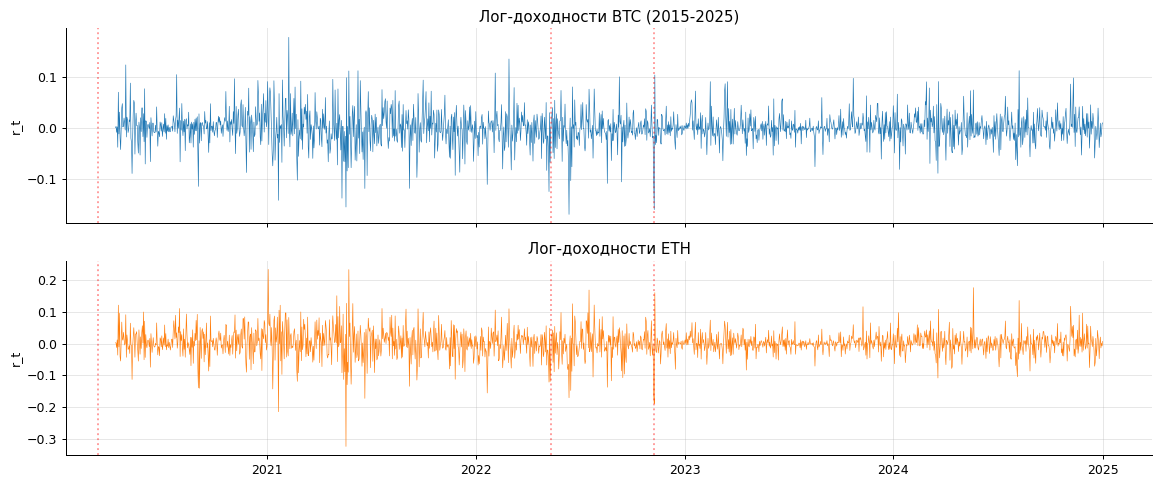

In [8]:
# Доходности BTC и ETH во времени — посмотрим, где случались «дикие» дни
fig, ax = plt.subplots(2, 1, figsize=(13, 5.5), sharex=True)
ax[0].plot(rets_full.index, rets_full['BTC'], lw=0.5, c='C0')
ax[0].set_title("Лог-доходности BTC (2015-2025)"); ax[0].set_ylabel("r_t")
ax[1].plot(rets_full.index, rets_full['ETH'], lw=0.5, c='C1')
ax[1].set_title("Лог-доходности ETH"); ax[1].set_ylabel("r_t")
for a in ax:
    for d, lab in [('2020-03-12','COVID'),('2022-05-12','LUNA'),('2022-11-08','FTX')]:
        a.axvline(pd.Timestamp(d, tz='UTC'), c='r', ls=':', alpha=0.4)
plt.tight_layout(); plt.show()

Глаз замечает кластеризацию волатильности — спокойные периоды сменяются «грозами», и эти
грозы группируются вокруг известных событий. Это стилизованный факт №1.

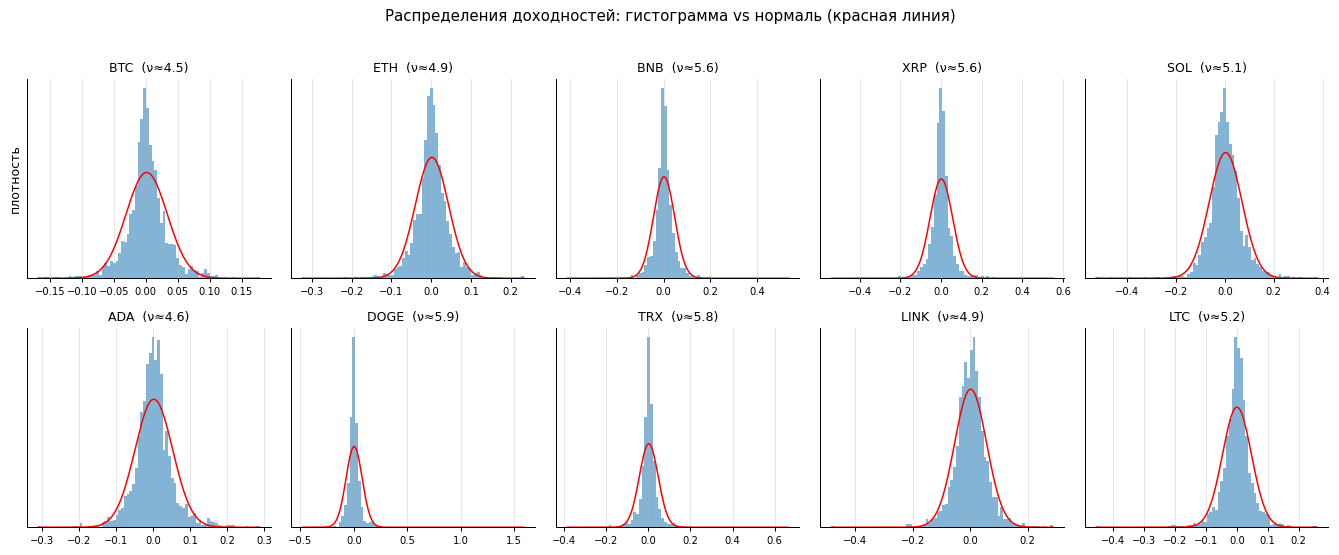

In [9]:
# Распределения: гистограмма+KDE и сверху нормаль с теми же mu, sigma
fig, axes = plt.subplots(2, 5, figsize=(15, 6), sharey=False)
for ax, c in zip(axes.flat, TOP10_POPULAR):
    r = rets_full[c].dropna()
    ax.hist(r, bins=80, density=True, alpha=0.55, color='C0')
    x = np.linspace(r.min(), r.max(), 200)
    ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), 'r', lw=1.2, label='Normal')
    ax.set_title(f"{c}  (ν≈{4*stats.kurtosis(r,fisher=True)/(stats.kurtosis(r,fisher=True)+2)+2:.1f})",
                 fontsize=10)
    ax.set_yticks([]); ax.tick_params(labelsize=8)
axes.flat[0].set_ylabel("плотность")
plt.suptitle("Распределения доходностей: гистограмма vs нормаль (красная линия)", y=1.02)
plt.tight_layout(); plt.show()

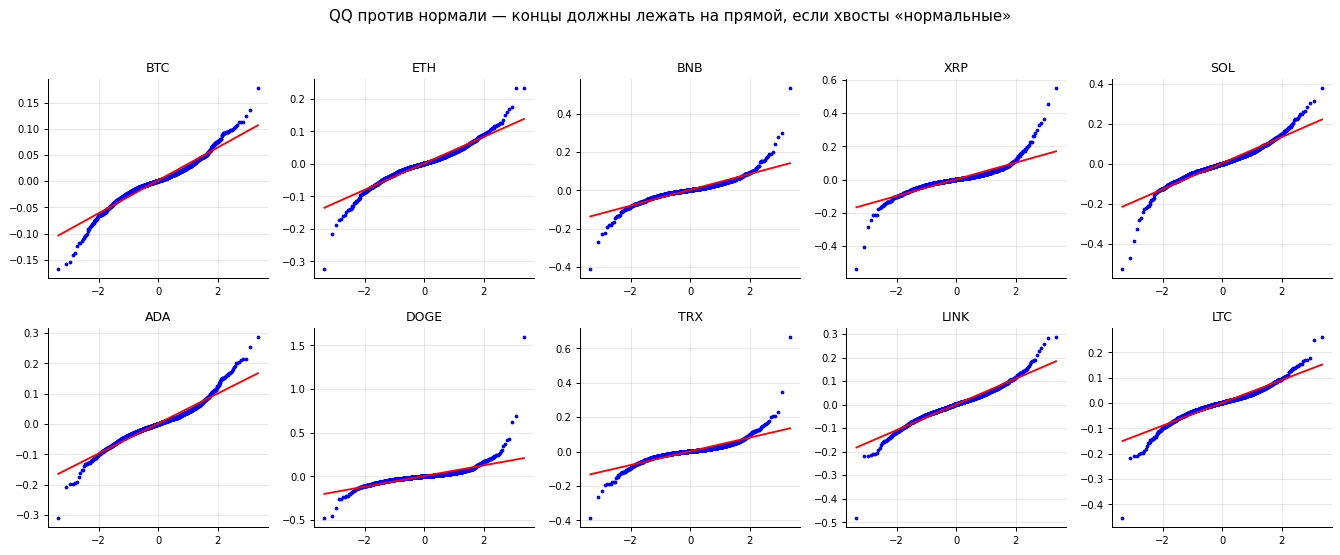

In [10]:
# QQ-графики против нормали — тяжёлые хвосты должны выгибать концы
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, c in zip(axes.flat, TOP10_POPULAR):
    r = rets_full[c].dropna()
    stats.probplot(r, dist='norm', plot=ax)
    ax.set_title(c, fontsize=10); ax.set_xlabel(''); ax.set_ylabel(''); ax.tick_params(labelsize=8)
    ax.get_lines()[0].set_markersize(2)
plt.suptitle("QQ против нормали — концы должны лежать на прямой, если хвосты «нормальные»", y=1.02)
plt.tight_layout(); plt.show()

In [11]:
# Численные характеристики, отранжированные
desc = pd.DataFrame({
    'ann_vol': rets_full.std() * np.sqrt(365),
    'skew': rets_full.skew(),
    'kurtosis': rets_full.kurtosis(),
    'min_day': rets_full.min(),
    'max_day': rets_full.max(),
}).round(3)
desc['ann_return'] = (rets_full.mean() * 365).round(3)
print("Описательная статистика (отсортировано по эксцессу — тяжести хвостов):")
display(desc.sort_values('kurtosis', ascending=False))

Описательная статистика (отсортировано по эксцессу — тяжести хвостов):


,ann_vol,skew,kurtosis,min_day,max_day,ann_return
DOGE,1.443,6.353,124.032,-0.480,1.594,1.076
TRX,0.858,1.602,36.143,-0.387,0.665,0.639
BNB,0.859,0.691,20.423,-0.412,0.533,0.833
XRP,1.062,0.786,19.579,-0.538,0.549,0.532
LTC,0.894,-0.655,8.288,-0.455,0.260,0.192
SOL,1.286,-0.245,6.554,-0.528,0.378,1.124
LINK,1.068,-0.230,5.395,-0.483,0.287,0.403
ETH,0.800,-0.283,5.091,-0.324,0.233,0.645
ADA,0.971,0.362,3.854,-0.310,0.287,0.702
BTC,0.615,-0.099,3.426,-0.168,0.178,0.554


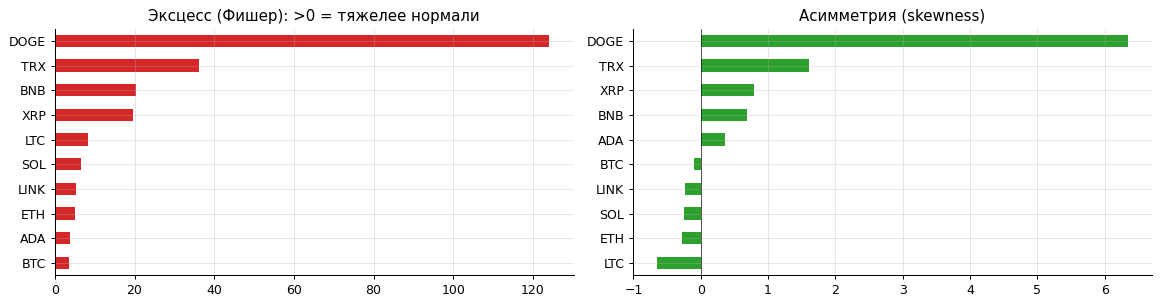

In [12]:
# Эксцесс и асимметрия — наглядно
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
desc['kurtosis'].sort_values().plot.barh(ax=ax[0], color='C3')
ax[0].set_title("Эксцесс (Фишер): >0 = тяжелее нормали"); ax[0].axvline(0, c='k', lw=0.5)
desc['skew'].sort_values().plot.barh(ax=ax[1], color='C2')
ax[1].set_title("Асимметрия (skewness)"); ax[1].axvline(0, c='k', lw=0.5)
plt.tight_layout(); plt.show()

Ровно то, чего ждали: эксцесс зашкаливает у всех (десятки!), особенно у LINK и SOL — у
них в выборке есть отдельные дни с движением 30%+. Это уже подсказка, что нормальная
дельта-VaR-модель здесь будет систематически *занижать* риск.

## 3. Просадки

Цифры дисперсии не передают эмоций, которые испытывает портфель в просадке. Посмотрим на
кривые «расстояния до исторического максимума» — то, как ощущает риск настоящий держатель.

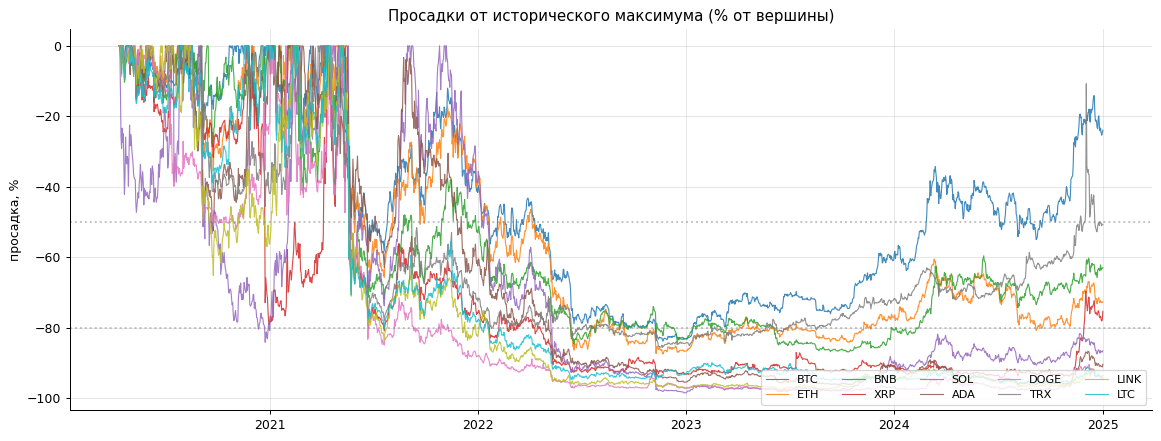

In [13]:
def drawdowns(s):
    s = s.dropna()
    cum = (1 + s).cumprod()
    return cum / cum.cummax() - 1

dd_simple = rets_full.apply(drawdowns)
fig, ax = plt.subplots(figsize=(13, 5))
for c in TOP10_POPULAR:
    ax.plot(dd_simple.index, dd_simple[c]*100, lw=0.9, alpha=0.85, label=c)
ax.set_title("Просадки от исторического максимума (% от вершины)")
ax.set_ylabel("просадка, %"); ax.axhline(-80, c='gray', ls=':', alpha=0.5)
ax.axhline(-50, c='gray', ls=':', alpha=0.5)
ax.legend(ncol=5, fontsize=9, loc='lower right'); plt.tight_layout(); plt.show()

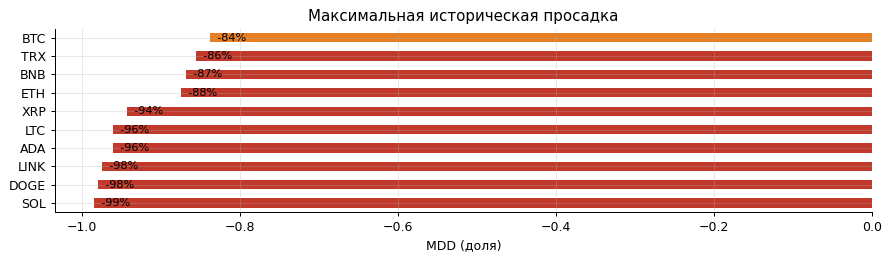

In [14]:
# Максимальная просадка по каждой монете
mdd = dd_simple.min().sort_values()
fig, ax = plt.subplots(figsize=(10, 3))
mdd.plot.barh(ax=ax, color=['#c0392b' if v < -0.85 else '#e67e22' if v < -0.7 else '#f1c40f' for v in mdd])
ax.set_title("Максимальная историческая просадка"); ax.set_xlabel("MDD (доля)")
for i, (c, v) in enumerate(mdd.items()):
    ax.text(v, i, f"  {v:.0%}", va='center', fontsize=9)
plt.tight_layout(); plt.show()

Каждая монета хотя бы раз падала на 70-90% от своего пика. Это вообще норма крипты, и
любой риск-модуль обязан быть готов к таким эпизодам — а не только к нормально
распределённым колебаниям.

## 4. Кластеризация волатильности

Возьмём скользящую σ и посмотрим, как она «дышит» во времени.

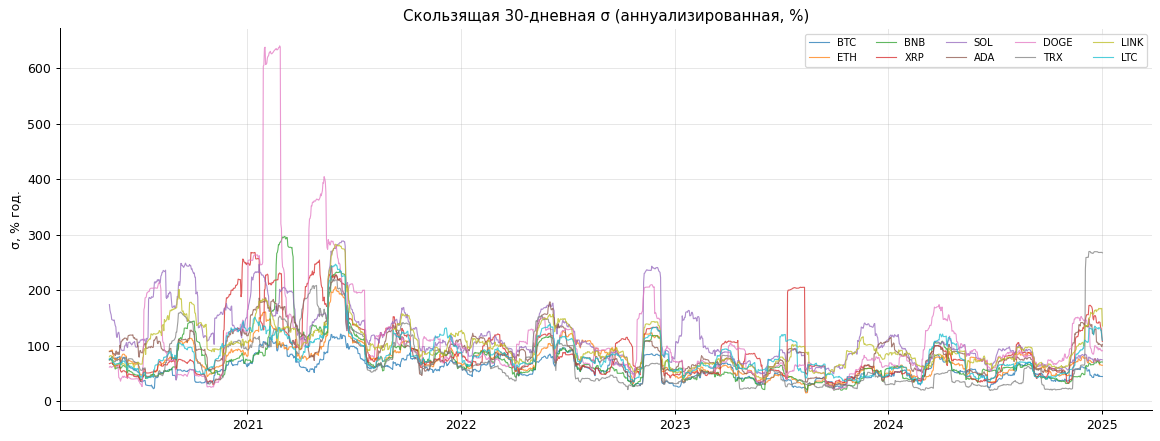

In [15]:
rolling_vol = rets_full.rolling(30).std() * np.sqrt(365)
fig, ax = plt.subplots(figsize=(13, 5))
for c in TOP10_POPULAR:
    ax.plot(rolling_vol.index, rolling_vol[c]*100, lw=0.9, alpha=0.75, label=c)
ax.set_title("Скользящая 30-дневная σ (аннуализированная, %)"); ax.set_ylabel("σ, % год.")
ax.legend(ncol=5, fontsize=8); plt.tight_layout(); plt.show()

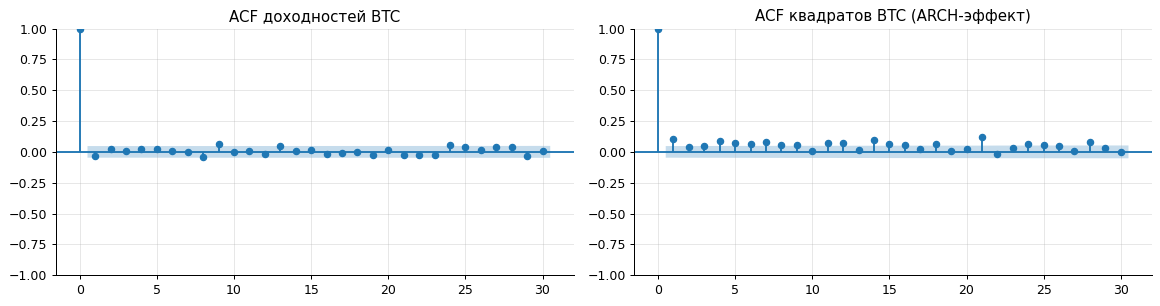

In [16]:
# Самое наглядное доказательство ARCH-эффекта — ACF доходностей vs ACF квадратов
from statsmodels.graphics.tsaplots import plot_acf
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
plot_acf(rets_full['BTC'].dropna(), lags=30, ax=ax[0], title='ACF доходностей BTC')
plot_acf(rets_full['BTC'].dropna()**2, lags=30, ax=ax[1], title='ACF квадратов BTC (ARCH-эффект)')
plt.tight_layout(); plt.show()

Слева — практически белый шум, справа — отчётливые автокорреляции квадратов на десятки
лагов. Классика. Это даёт право использовать GARCH-семейство.

## 5. Корреляции — постоянные и движущиеся

Сначала «безусловная» корреляционная матрица (по общему окну).

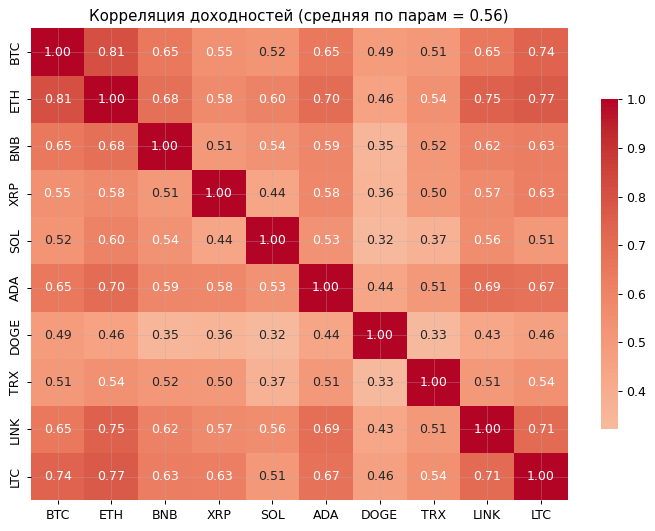

In [17]:
corr = rets_common.corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            cbar_kws={'shrink': 0.7})
mean_corr = corr.values[np.triu_indices(10, k=1)].mean()
ax.set_title(f"Корреляция доходностей (средняя по парам = {mean_corr:.2f})")
plt.tight_layout(); plt.show()

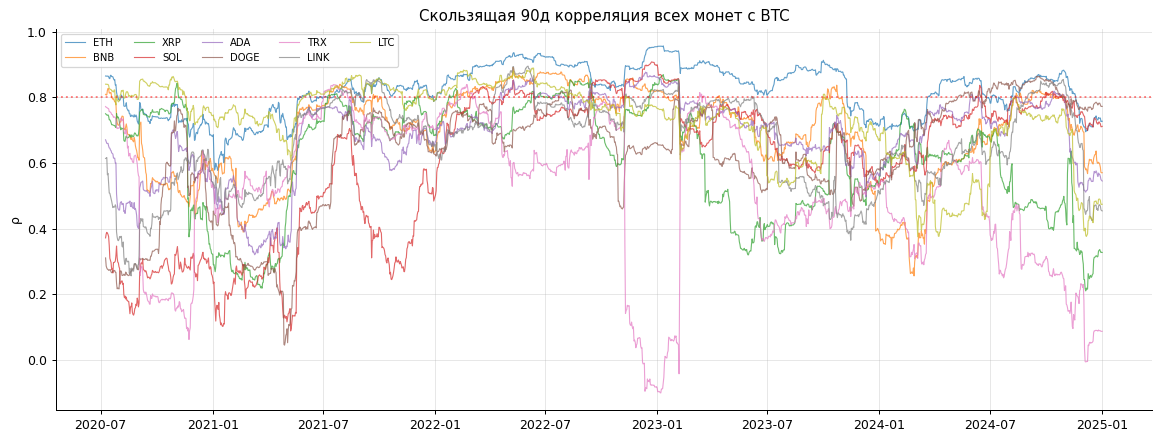

In [18]:
# Скользящая 90-дневная корреляция BTC с каждой из остальных монет
roll_corr = pd.DataFrame({c: rets_common['BTC'].rolling(90).corr(rets_common[c])
                          for c in TOP10_POPULAR if c != 'BTC'})
fig, ax = plt.subplots(figsize=(13, 5))
for c in roll_corr.columns:
    ax.plot(roll_corr.index, roll_corr[c], lw=0.9, alpha=0.7, label=c)
ax.set_title("Скользящая 90д корреляция всех монет с BTC")
ax.set_ylabel("ρ"); ax.axhline(0.8, c='r', ls=':', alpha=0.5)
ax.legend(ncol=5, fontsize=8); plt.tight_layout(); plt.show()

Корреляции *плавают* в диапазоне 0.3-0.95 и подскакивают в стресс-периодах. Это и есть
аргумент в пользу DCC-GARCH (динамические корреляции) и в пользу того, что
«диверсификация» в крипте — функция режима, а не константа.

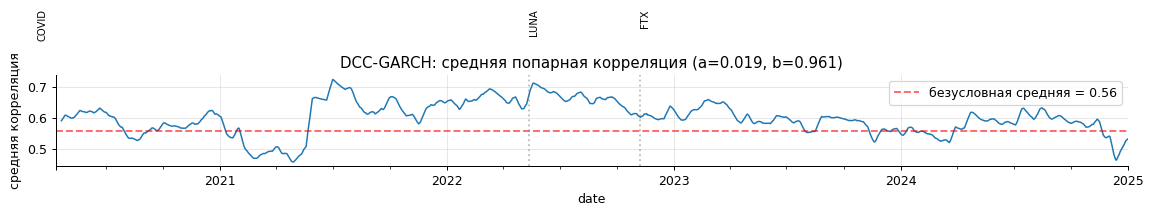

In [19]:
# DCC-GARCH (динамические условные корреляции)
dcc = cvm.dcc_garch(rets_common)
fig, ax = plt.subplots(figsize=(13, 4))
dcc.avg_corr_path.rolling(10).mean().plot(ax=ax, lw=1.2)
ax.axhline(mean_corr, c='r', ls='--', alpha=0.6, label=f"безусловная средняя = {mean_corr:.2f}")
for d, lab in [('2020-03-12','COVID'),('2022-05-12','LUNA'),('2022-11-08','FTX')]:
    ax.axvline(pd.Timestamp(d, tz='UTC'), c='gray', ls=':', alpha=0.5)
    ax.text(pd.Timestamp(d, tz='UTC'), 0.95, lab, rotation=90, fontsize=8, va='top')
ax.set_title(f"DCC-GARCH: средняя попарная корреляция (a={dcc.a:.3f}, b={dcc.b:.3f})")
ax.set_ylabel("средняя корреляция"); ax.legend(); plt.tight_layout(); plt.show()

## 6. Стохастическая модель волатильности

Сравним пару спецификаций GARCH-семейства на BTC и выберем лучшую по BIC.

In [20]:
best_btc, table_btc = vol.select_best_garch(rets_full['BTC'].dropna(),
                                              criterion='bic', horizon=10)
print("Сравнение спецификаций для BTC:")
display(table_btc.round(2))
print(f"\nЛучшая: {best_btc.vol} + {best_btc.dist}, ν={best_btc.nu:.2f}, BIC={best_btc.bic:.1f}")

Сравнение спецификаций для BTC:


,vol,dist,aic,bic,nu,error
0,GARCH,t,8526.57,8553.84,3.23,
1,GJR,t,8527.54,8560.27,3.26,
2,GJR,skewt,8527.59,8565.77,NaN,
3,GARCH,normal,8798.13,8819.94,NaN,
4,EGARCH,t,NaN,NaN,NaN,Analytic forecasts not available for hor



Лучшая: GARCH + t, ν=3.23, BIC=8553.8


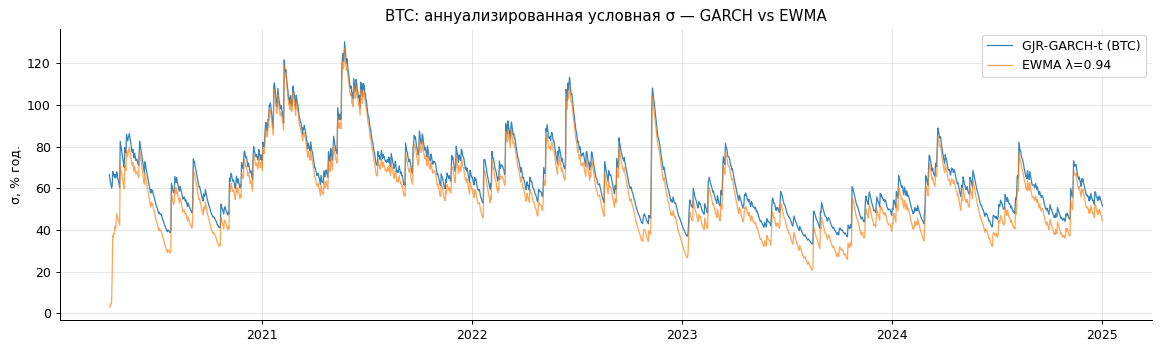

In [21]:
# Условная σ из GJR-GARCH-t против быстрого EWMA
g_sigma_ann = best_btc.sigma * np.sqrt(365)
ewma_sigma_ann = vol.ewma_volatility(rets_full['BTC'].dropna(), lam=0.94) * np.sqrt(365)
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(g_sigma_ann.index, g_sigma_ann*100, lw=1, label=f"GJR-GARCH-t (BTC)", alpha=0.9)
ax.plot(ewma_sigma_ann.index, ewma_sigma_ann*100, lw=1, label="EWMA λ=0.94", alpha=0.7)
ax.set_title("BTC: аннуализированная условная σ — GARCH vs EWMA")
ax.set_ylabel("σ, % год."); ax.legend(); plt.tight_layout(); plt.show()

GARCH плавнее и реагирует с задержкой, EWMA — нервный, но честно следует за последними
ударами. Для дневного risk-контура они оба полезны и часто используются параллельно.

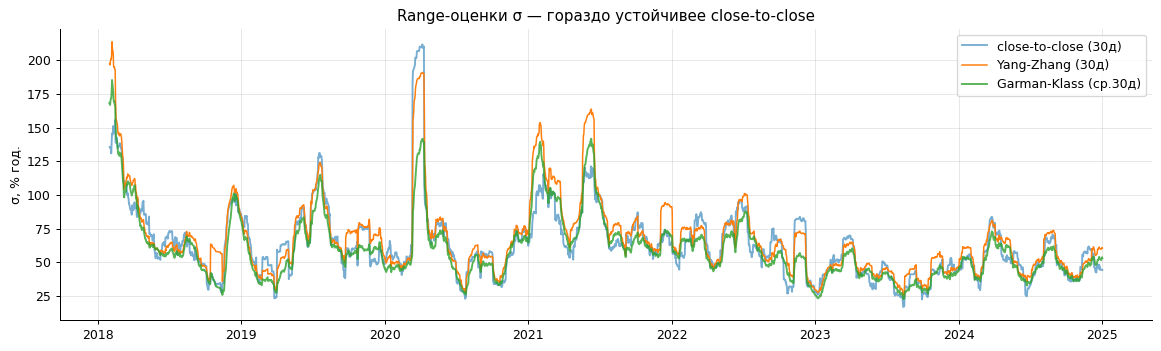

In [22]:
# Range-оценки σ из OHLC (если доступен реальный OHLC) — обычно куда тише близкой-близкой
btc_ohlc = CryptoDataLoader(('BTC',), mode='auto').load_ohlcv('BTC','2018-01-01','2025-01-01','1d')
pk = vol.parkinson_vol(btc_ohlc); gk = vol.garman_klass_vol(btc_ohlc)
yz = vol.yang_zhang_vol(btc_ohlc, 30)
cc = vol.log_returns(btc_ohlc['close']).rolling(30).std()
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(cc.index, cc*np.sqrt(365)*100, label='close-to-close (30д)', alpha=0.6)
ax.plot(yz.index, yz*np.sqrt(365)*100, label='Yang-Zhang (30д)', lw=1.2)
ax.plot(gk.rolling(30).mean().index, gk.rolling(30).mean()*np.sqrt(365)*100,
        label='Garman-Klass (ср.30д)', alpha=0.8)
ax.set_title("Range-оценки σ — гораздо устойчивее close-to-close")
ax.set_ylabel("σ, % год."); ax.legend(); plt.tight_layout(); plt.show()

HAR-RV: c=4.59e-04, β_d=0.37, β_w=0.11, β_m=0.19,  R²=0.22
Прогноз дневной σ = 0.0271 (51.8% год.)


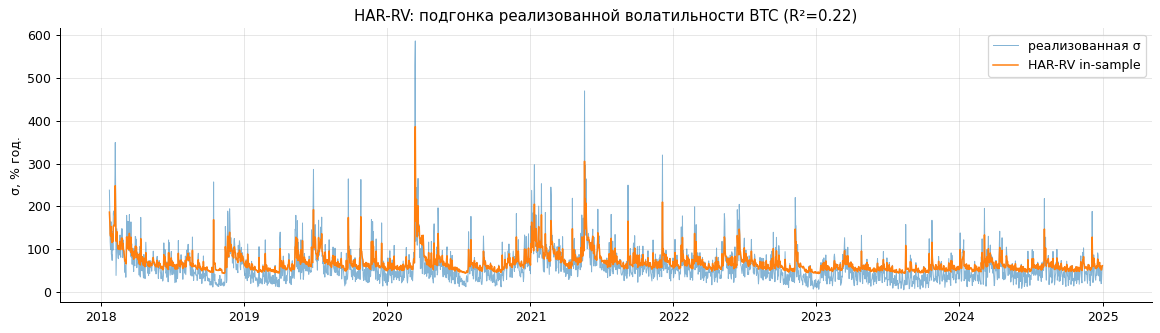

In [23]:
# HAR-RV (Corsi): прогноз реализованной дисперсии каскадом «день/неделя/месяц»
rv = (vol.garman_klass_vol(btc_ohlc) ** 2).dropna()
har = vol.har_rv(rv)
print(f"HAR-RV: c={har.params['c']:.2e}, β_d={har.params['beta_d']:.2f}, "
      f"β_w={har.params['beta_w']:.2f}, β_m={har.params['beta_m']:.2f},  R²={har.r2:.2f}")
print(f"Прогноз дневной σ = {har.forecast_vol:.4f} ({har.forecast_vol*np.sqrt(365):.1%} год.)")
fig, ax = plt.subplots(figsize=(13, 3.8))
ax.plot(np.sqrt(rv.reindex(har.fitted.index))*np.sqrt(365)*100, lw=0.8, label='реализованная σ', alpha=0.55)
ax.plot(np.sqrt(har.fitted)*np.sqrt(365)*100, lw=1.2, label='HAR-RV in-sample')
ax.set_title(f"HAR-RV: подгонка реализованной волатильности BTC (R²={har.r2:.2f})")
ax.set_ylabel("σ, % год."); ax.legend(); plt.tight_layout(); plt.show()

## 7. VaR и ES — оценим хвост разными способами

Будем смотреть на портфель из 10 монет с равными весами (как «нулевую» точку отсчёта), на
горизонтах 1 и 10 дней, на уровнях 99% (VaR) и 97.5% (ES).

In [24]:
w_eq = np.ones(10) / 10
port = pd.Series(rets_common.values @ w_eq, index=rets_common.index, name='equal-weight')
print(f"Равновзвешенный портфель: {len(port)} дней, "
      f"годовая σ = {port.std()*np.sqrt(365):.1%}, "
      f"средняя ann. доходность = {port.mean()*365:.1%}")

Равновзвешенный портфель: 1727 дней, годовая σ = 75.1%, средняя ann. доходность = 67.0%


In [25]:
# Достаточно сложная модель волатильности портфеля
garch_port = vol.GARCHModel('GJR', 't').fit(port, horizon=10)
print(f"Портфель GJR-GARCH-t: ν={garch_port.nu:.2f}, BIC={garch_port.bic:.1f}")

# Все методы VaR/ES в одной таблице, два горизонта
cmp1 = ve.compare_methods(port, horizon=1, garch_result=garch_port).round(4)
cmp10 = ve.compare_methods(port, horizon=10, garch_result=garch_port).round(4)
print("\n--- горизонт 1 день ---"); display(cmp1)
print("\n--- горизонт 10 дней ---"); display(cmp10)

Портфель GJR-GARCH-t: ν=4.27, BIC=9180.0

--- горизонт 1 день ---


,method,horizon,VaR_99,ES_97.5
0,historical,1,0.1199,0.1224
1,parametric_normal,1,0.0896,0.0901
2,parametric_t,1,0.1007,0.1054
3,cornish_fisher,1,0.1800,0.1961
4,ewma_normal,1,0.0820,0.0824
5,garch_GJR_t,1,0.0906,0.0961
6,fhs,1,0.1030,0.1055
7,evt_pot_mle,1,0.1170,0.1245



--- горизонт 10 дней ---


,method,horizon,VaR_99,ES_97.5
0,historical,10,0.3792,0.3871
1,parametric_normal,10,0.2709,0.2724
2,parametric_t,10,0.3058,0.3209
3,cornish_fisher,10,0.5566,0.6077
4,ewma_normal,10,0.2466,0.2479
5,garch_GJR_t,10,0.2827,0.3005
6,fhs,10,0.2654,0.2654
7,evt_pot_mle,10,0.3701,0.3939


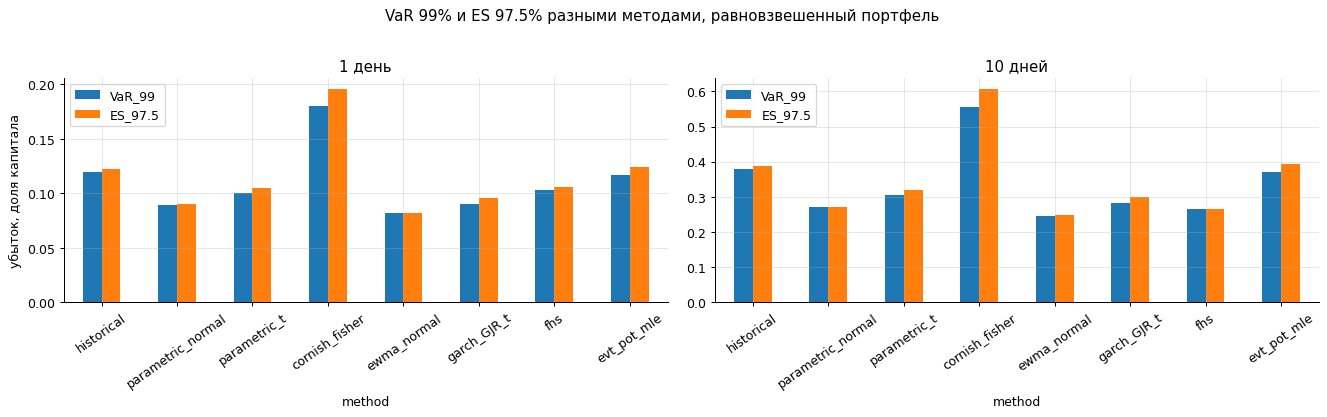

In [26]:
# Визуальное сравнение методов
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
cmp1.set_index('method')[['VaR_99', 'ES_97.5']].plot.bar(ax=ax[0])
ax[0].set_title("1 день"); ax[0].set_ylabel("убыток, доля капитала")
ax[0].tick_params(axis='x', labelrotation=35); ax[0].legend(loc='upper left')
cmp10.set_index('method')[['VaR_99', 'ES_97.5']].plot.bar(ax=ax[1])
ax[1].set_title("10 дней"); ax[1].tick_params(axis='x', labelrotation=35); ax[1].legend(loc='upper left')
plt.suptitle("VaR 99% и ES 97.5% разными методами, равновзвешенный портфель", y=1.02)
plt.tight_layout(); plt.show()

Обратите внимание, насколько `parametric_normal` ниже остальных. Это нормальное
распределение «не видит» хвост, и эта недооценка — главная причина, по которой
дельта-нормальный VaR не годится для крипты.

## 8. Хвост подробнее: EVT (POT/GPD) и условный EVT

Метод Peaks-Over-Threshold: высокий порог $u$, обобщённое распределение Парето на
превышениях. Хорошая «инженерная» диагностика — *mean-excess plot*: если эта функция
растёт примерно линейно с порога, GPD адекватна.

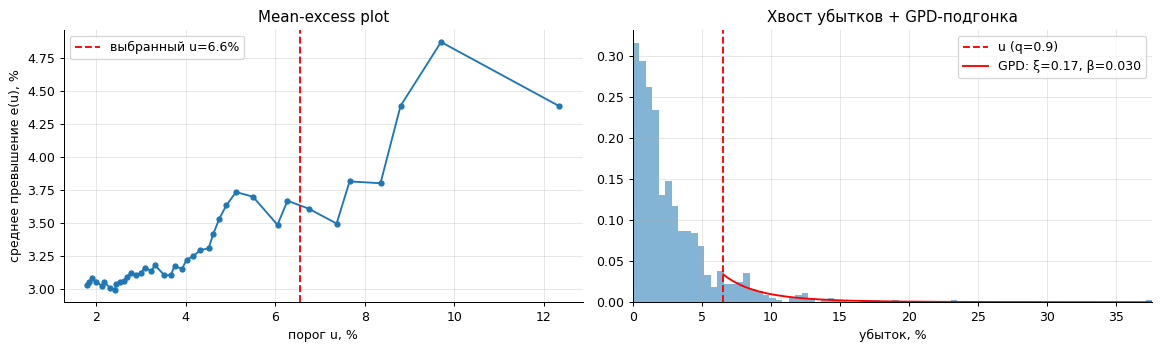

Индекс хвоста Хилла α = 2.84  (α < 4 => не существует 4-го момента)


In [27]:
losses = (-port[port < 0]).values
us, me = evt.mean_excess_plot_data(losses)
fit = evt.fit_gpd(losses, threshold_q=0.90)
hill = evt.hill_estimator(losses)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(us*100, me*100, 'o-', ms=4); ax[0].set_xlabel("порог u, %")
ax[0].set_ylabel("среднее превышение e(u), %"); ax[0].set_title("Mean-excess plot")
ax[0].axvline(fit.threshold*100, c='r', ls='--', label=f"выбранный u={fit.threshold:.1%}")
ax[0].legend()

ax[1].hist(losses*100, bins=80, density=True, alpha=0.55)
ax[1].axvline(fit.threshold*100, c='r', ls='--', label=f"u (q={0.90})")
xs = np.linspace(fit.threshold, losses.max(), 200)
gpd_pdf = (1/fit.beta) * (1 + fit.xi*(xs-fit.threshold)/fit.beta) ** (-1/fit.xi - 1)
gpd_pdf *= fit.n_exceed / fit.n_total
ax[1].plot(xs*100, gpd_pdf/100, 'r', lw=1.5, label=f"GPD: ξ={fit.xi:.2f}, β={fit.beta:.3f}")
ax[1].set_xlim(0, losses.max()*100); ax[1].set_xlabel("убыток, %")
ax[1].set_title("Хвост убытков + GPD-подгонка"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"Индекс хвоста Хилла α = {hill:.2f}  (α < 4 => не существует 4-го момента)")

In [28]:
# Условный EVT (McNeil-Frey): GARCH + POT на стандартизованных остатках
cevt = evt.conditional_evt(port, garch_port, 0.99, 0.975, threshold_q=0.90)
pot = evt.pot_var_es(port, 0.99, 0.975, threshold_q=0.90)
ev_compare = pd.DataFrame([
    ('Normal', ve.parametric_var_es(port.mean(), port.std(), 0.99, 0.975, 1, 'normal')),
    ('Historical', ve.historical_var_es(port, 0.99, 0.975, 1)),
    ('GARCH-t', ve.garch_var_es(garch_port, 0.99, 0.975, 1)),
    ('EVT POT', pot),
    ('Conditional EVT', cevt),
], columns=['метод', 'est'])
ev_compare['VaR_99'] = [e.var for e in ev_compare['est']]
ev_compare['ES_97.5'] = [e.es for e in ev_compare['est']]
display(ev_compare.drop(columns='est').round(4))

,метод,VaR_99,ES_97.5
0,Normal,0.0896,0.0901
1,Historical,0.1199,0.1224
2,GARCH-t,0.0924,0.0979
3,EVT POT,0.1170,0.1245
4,Conditional EVT,0.1017,0.1057


## 9. Бэктестинг VaR

Скользящий историчекий VaR с окном 252 дня — пробои должны составлять ровно 1% при
уровне 99%.

In [29]:
engine = RiskEngine(RiskConfig(universe=TOP10_POPULAR)).set_returns(rets_common)
bt_hist = engine.backtest_var(weights=dict(zip(TOP10_POPULAR, w_eq)),
                              method='historical', window=252)
print(f"Пробои: {bt_hist['n_violations']}/{bt_hist['n_obs']} "
      f"= {bt_hist['violation_rate']:.2%}  (ожидаемо {bt_hist['expected_rate']:.2%})")
display(bt_hist['backtest_table'][['test','statistic','p_value','verdict']].round(4))

Пробои: 19/1475 = 1.29%  (ожидаемо 1.00%)


,test,statistic,p_value,verdict
0,Kupiec POF,1.1338,0.2870,НЕ отвергаем H0: модель адекватна
1,Christoffersen Independence,5.2312,0.0222,ОТВЕРГАЕМ H0: модель некорректна
2,Christoffersen CC,6.3650,0.0415,ОТВЕРГАЕМ H0: модель некорректна
3,Duration (Weibull),5.0449,0.0247,ОТВЕРГАЕМ H0: модель некорректна
4,Engle-Manganelli DQ,23.4879,0.0006,ОТВЕРГАЕМ H0: модель некорректна
5,Berkowitz,0.8731,0.6463,НЕ отвергаем H0: модель адекватна


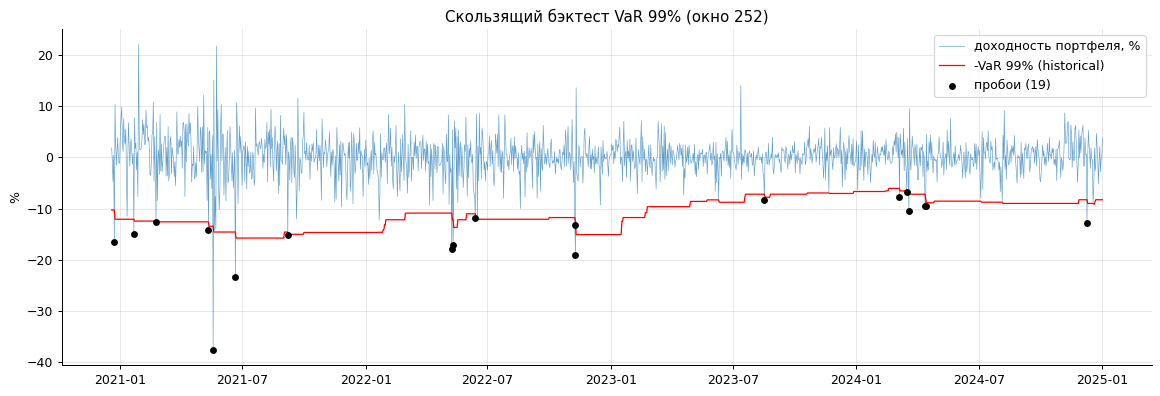

In [30]:
# Визуальный бэктест — где пробои реально случались
vs = bt_hist['var_series'].dropna()
rr = bt_hist['realized'].reindex(vs.index)
breach = rr < -vs
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(rr.index, rr*100, lw=0.5, alpha=0.7, label='доходность портфеля, %')
ax.plot(vs.index, -vs*100, c='r', lw=1, label='-VaR 99% (historical)')
ax.scatter(rr.index[breach], rr[breach]*100, c='k', s=20, zorder=5,
           label=f"пробои ({int(breach.sum())})")
ax.set_title("Скользящий бэктест VaR 99% (окно 252)"); ax.set_ylabel("%")
ax.legend(); plt.tight_layout(); plt.show()

,метод,пробои%,ожидание%,Kupiec_p,светофор
0,historical,1.288,1.0,0.287,GREEN
1,ewma,3.051,1.0,0.000,RED
2,parametric,2.169,1.0,0.000,RED


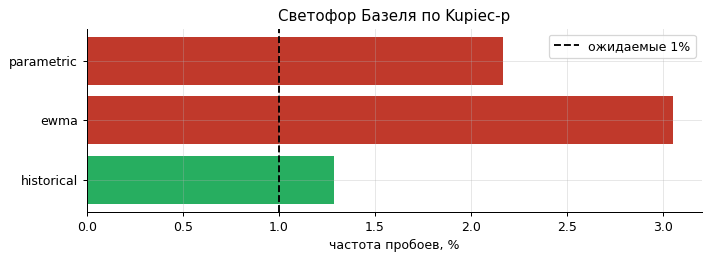

In [31]:
# Сравним методы: historical / ewma / parametric — по числу пробоев и Kupiec-p
rows = []
for m in ['historical', 'ewma', 'parametric']:
    r = engine.backtest_var(weights=dict(zip(TOP10_POPULAR, w_eq)),
                            method=m, window=252)
    k = r['backtest_table'].set_index('test').loc['Kupiec POF']
    rows.append({'метод': m, 'пробои%': r['violation_rate']*100,
                 'ожидание%': r['expected_rate']*100,
                 'Kupiec_p': k['p_value'], 'светофор': bt.traffic_light(k['p_value'])})
bt_summary = pd.DataFrame(rows).round(3)
display(bt_summary)
fig, ax = plt.subplots(figsize=(8, 3))
colors = {'GREEN':'#27ae60','YELLOW':'#f1c40f','RED':'#c0392b'}
ax.barh(bt_summary['метод'], bt_summary['пробои%'],
        color=[colors[c] for c in bt_summary['светофор']])
ax.axvline(1.0, c='k', ls='--', label='ожидаемые 1%')
ax.set_xlabel("частота пробоев, %"); ax.set_title("Светофор Базеля по Kupiec-p"); ax.legend()
plt.tight_layout(); plt.show()

## 10. Бэктест ES и модельный риск

VaR — это только квантиль; форма хвоста за ним — это уже ES, и для ES свой бэктест.

In [32]:
# Скользящие ряды VaR/ES (параметрический-t) и тесты Acerbi-Szekely
rv_ = port.values; n_ = len(rv_)
var_s = np.full(n_, np.nan); es_s = np.full(n_, np.nan)
for t in range(252, n_):
    h = rv_[t-252:t]
    e = ve.parametric_var_es(h.mean(), h.std(), 0.99, 0.975, 1, 't', 5)
    var_s[t] = e.var; es_s[t] = e.es
m_ = ~np.isnan(var_s)
t1 = bt.acerbi_szekely_test1(rv_[m_], var_s[m_], es_s[m_])
t2 = bt.acerbi_szekely_es(rv_[m_], var_s[m_], es_s[m_])
print(t1); print(t2)

[Acerbi-Szekely ES (Test 1)] stat=0.316, p=0.0000 -> ОТВЕРГАЕМ H0: модель некорректна
[Acerbi-Szekely ES (Test 2)] stat=-0.035, p=0.0000 -> ОТВЕРГАЕМ H0: модель некорректна


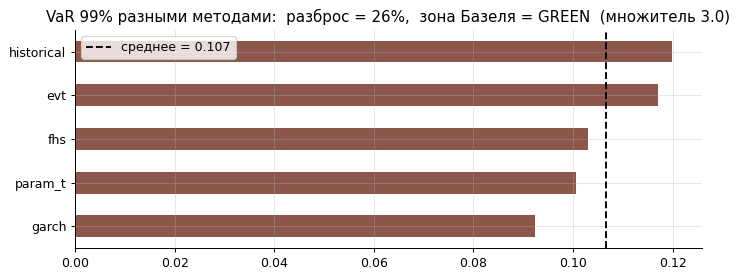

In [33]:
# Модельный риск: разброс оценок VaR между методами
mr = bt.model_risk_metrics({
    'historical': ve.historical_var_es(port, 0.99, 0.975, 1).var,
    'param_t':    ve.parametric_var_es(port.mean(), port.std(), 0.99, 0.975, 1, 't', 5).var,
    'garch':      ve.garch_var_es(garch_port, 0.99, 0.975, 1).var,
    'fhs':        ve.fhs_var_es(port, garch_port, 0.99, 0.975, 1).var,
    'evt':        evt.pot_var_es(port, 0.99, 0.975).var,
}, n_violations=int(bt_hist['n_violations']), n_obs=int(bt_hist['n_obs']))
fig, ax = plt.subplots(figsize=(8, 3.2))
pd.Series(mr['var_estimates']).sort_values().plot.barh(ax=ax, color='C5')
ax.axvline(mr['mean'], c='k', ls='--', label=f"среднее = {mr['mean']:.3f}")
ax.set_title(f"VaR 99% разными методами:  разброс = {mr['relative_spread']:.0%},  "
             f"зона Базеля = {mr['basel_zone']}  (множитель {mr['basel_multiplier']})")
ax.legend(); plt.tight_layout(); plt.show()

## 11. Эффективные границы и веса портфелей

Аннуализируем μ и Σ (по 365) и строим границу при четырёх режимах ограничений из
исходного ТЗ.

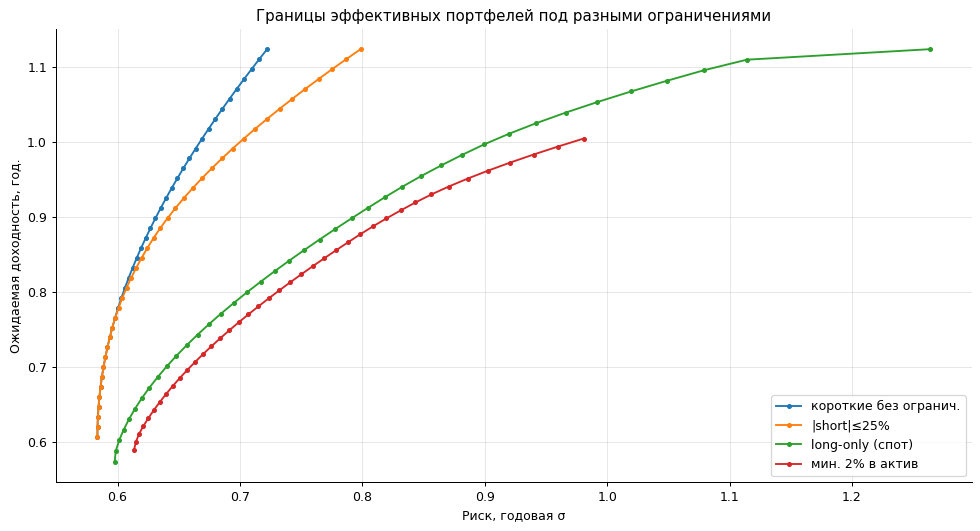

In [34]:
mu, cov = pf.mean_cov(rets_common, annualize=True)
opt = pf.PortfolioOptimizer(mu, cov, names=list(TOP10_POPULAR))

frontiers = {}
for c, label in [('long_short','короткие без огранич.'),
                 ('short_limit','|short|≤25%'),
                 ('long_only','long-only (спот)'),
                 ('min_weight','мин. 2% в актив')]:
    frontiers[label] = opt.efficient_frontier(40, c)

fig, ax = plt.subplots(figsize=(11, 6))
for label, fr in frontiers.items():
    ax.plot([p.vol for p in fr], [p.ret for p in fr], '-o', ms=3, label=label)
ax.set_xlabel("Риск, годовая σ"); ax.set_ylabel("Ожидаемая доходность, год.")
ax.set_title("Границы эффективных портфелей под разными ограничениями")
ax.legend(); plt.tight_layout(); plt.show()

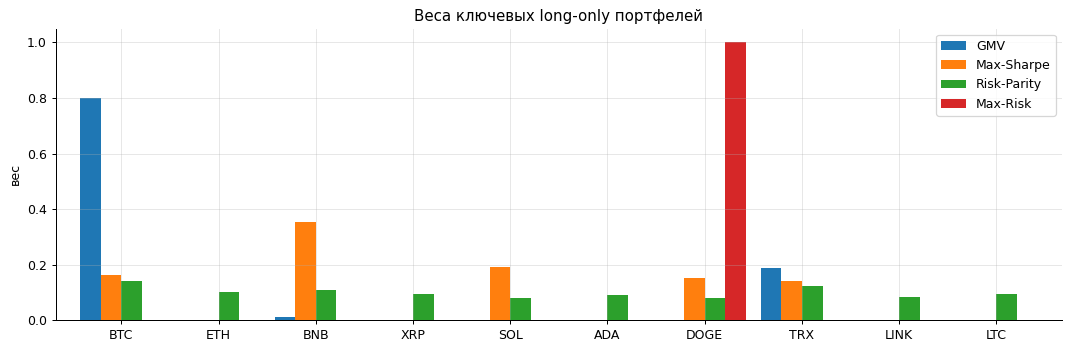

In [35]:
# Ключевые портфели и их веса
gmv = opt.min_variance(constraint='long_only')
msr = opt.max_sharpe(constraint='long_only')
rp  = opt.risk_parity()
mxr = opt.max_risk(constraint='long_only')
W = pd.DataFrame({'GMV': gmv.weights, 'Max-Sharpe': msr.weights,
                  'Risk-Parity': rp.weights, 'Max-Risk': mxr.weights},
                 index=TOP10_POPULAR)
fig, ax = plt.subplots(figsize=(12, 4))
W.plot.bar(ax=ax, width=0.85)
ax.set_title("Веса ключевых long-only портфелей"); ax.set_ylabel("вес")
ax.legend(loc='upper right'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

Число обусловленности:  выборочная Σ = 69,  Ledoit-Wolf = 54 (δ=0.02)


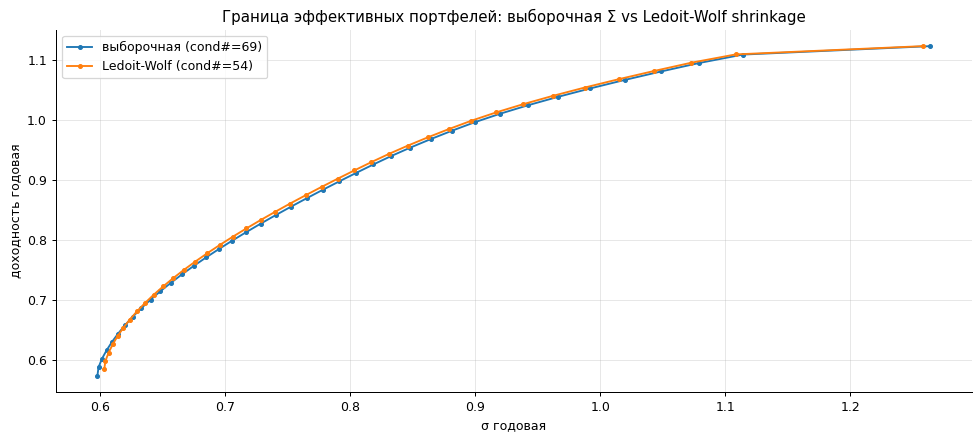

In [36]:
# Эффект shrinkage на портфельные веса (точнее — на устойчивость)
S = cvm.sample_cov(rets_common, annualize=True)
LW, d_lw = cvm.ledoit_wolf_cov(rets_common, annualize=True)
cn_s = cvm.condition_number(S); cn_l = cvm.condition_number(LW)
print(f"Число обусловленности:  выборочная Σ = {cn_s:.0f},  Ledoit-Wolf = {cn_l:.0f}"
      f" (δ={d_lw:.2f})")
fig, ax = plt.subplots(figsize=(11, 5))
for cmat, lab in [(S, f"выборочная (cond#={cn_s:.0f})"),
                  (LW, f"Ledoit-Wolf (cond#={cn_l:.0f})")]:
    o = pf.PortfolioOptimizer(mu, cmat, names=list(TOP10_POPULAR))
    fr = o.efficient_frontier(40, 'long_only')
    ax.plot([p.vol for p in fr], [p.ret for p in fr], '-o', ms=3, label=lab)
ax.set_xlabel("σ годовая"); ax.set_ylabel("доходность годовая")
ax.set_title("Граница эффективных портфелей: выборочная Σ vs Ledoit-Wolf shrinkage")
ax.legend(); plt.tight_layout(); plt.show()

## 12. Беты к рынку (BTC) — рыночная модель

В крипте «рыночный индекс» по умолчанию — это BTC. Оценим обычные и
скорректированные (по Блюму) беты, и сравним границы при разных способах оценки Σ.

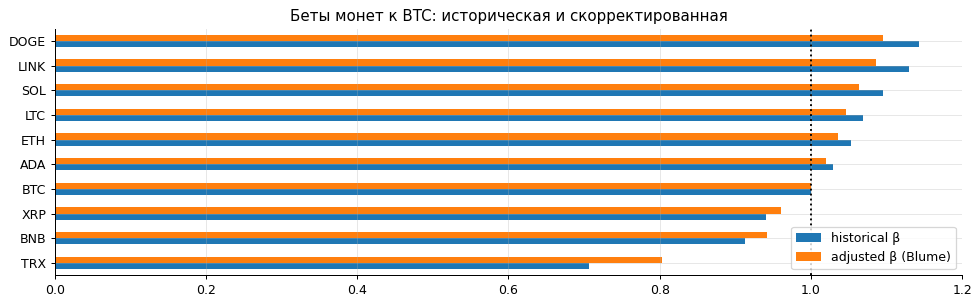

,historical β,adjusted β (Blume)
TRX,0.71,0.80
BNB,0.91,0.94
XRP,0.94,0.96
BTC,1.00,1.00
ADA,1.03,1.02
ETH,1.05,1.04
LTC,1.07,1.05
SOL,1.10,1.06
LINK,1.13,1.09
DOGE,1.14,1.10


In [37]:
be = pf.estimate_betas(rets_common, market='BTC')
betas = pd.DataFrame({'historical β': be.betas, 'adjusted β (Blume)': be.adjusted_betas}
                     ).sort_values('historical β')
fig, ax = plt.subplots(figsize=(11, 3.5))
betas.plot.barh(ax=ax); ax.axvline(1.0, c='k', ls=':')
ax.set_title("Беты монет к BTC: историческая и скорректированная")
plt.tight_layout(); plt.show()
display(betas.round(2))

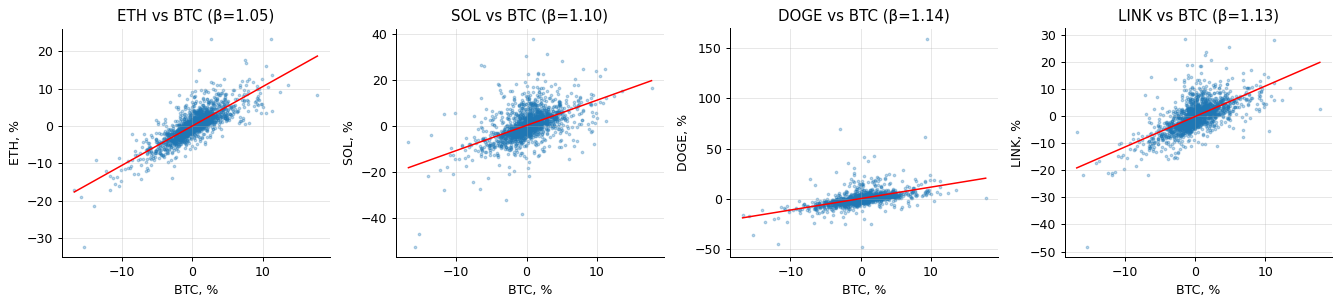

In [38]:
# Scatter монета vs BTC + регрессия (по 4 показательным монетам)
sample = ['ETH', 'SOL', 'DOGE', 'LINK']
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, c in zip(axes, sample):
    x, y = rets_common['BTC'], rets_common[c]
    ax.scatter(x*100, y*100, s=4, alpha=0.3)
    b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs*100, np.polyval(b, xs)*100, 'r', lw=1.2)
    ax.set_title(f"{c} vs BTC (β={b[0]:.2f})"); ax.set_xlabel('BTC, %'); ax.set_ylabel(f'{c}, %')
plt.tight_layout(); plt.show()

## 13. Ликвидность и микроструктура: цена реальности

VaR — это «бумажный» риск. Реальная стоимость закрытия позиции состоит из спреда,
рыночного воздействия и комиссий. Для HFT эти компоненты часто сравнимы с ценовым риском.

In [39]:
# 1) Bangia LVaR: ценовой VaR + компонента ликвидности
price_var = ve.historical_var_es(port, 0.99, 0.975, 1).var
mu_s, sd_s = 0.0006, 0.0003   # реалистичные значения отн. спреда для топ-10 крипты
lvar = liq.bangia_lvar(price_var, mu_s, sd_s, spread_mult=3.0)
print(lvar)

LVaR=0.1207 (price=0.1199 + liq=0.0008, liq-share=0.6%)


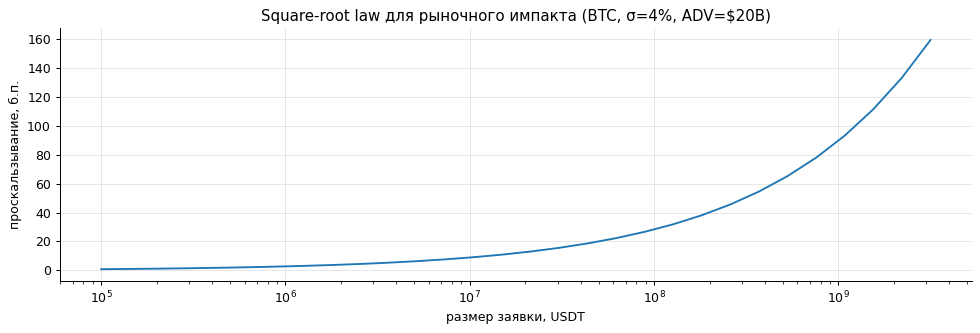

In [40]:
# 2) Square-root law — рыночный импакт vs размер заявки
adv = 2e10
sizes = np.logspace(5, 9.5, 30)
impact = np.array([liq.square_root_impact(s, adv, sigma=0.04) for s in sizes])
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.semilogx(sizes, impact*1e4, lw=1.5)
ax.set_xlabel("размер заявки, USDT"); ax.set_ylabel("проскальзывание, б.п.")
ax.set_title("Square-root law для рыночного импакта (BTC, σ=4%, ADV=$20B)")
plt.tight_layout(); plt.show()

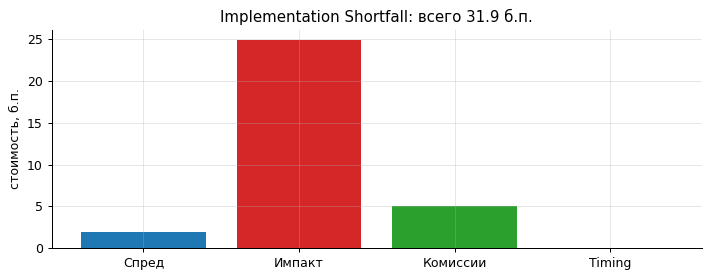

In [41]:
# 3) Implementation Shortfall на симулированном исполнении 100 BTC
np.random.seed(7)
dp = 75000
fills = dp * (1 + np.cumsum(np.random.normal(2e-4, 5e-4, 25)))
sizes_ = np.full(25, 4.0)
ish = liq.implementation_shortfall(dp, fills, sizes_, side='buy',
                                   half_spread=0.0002, fee_rate=0.0005)
fig, ax = plt.subplots(figsize=(8, 3.2))
parts = ['spread_cost_bps','impact_cost_bps','fees_bps','timing_cost_bps']
vals = [getattr(ish, p) for p in parts]
ax.bar(['Спред','Импакт','Комиссии','Timing'], vals, color=['C0','C3','C2','C4'])
ax.set_title(f"Implementation Shortfall: всего {ish.total_bps:.1f} б.п.")
ax.set_ylabel("стоимость, б.п.")
plt.tight_layout(); plt.show()

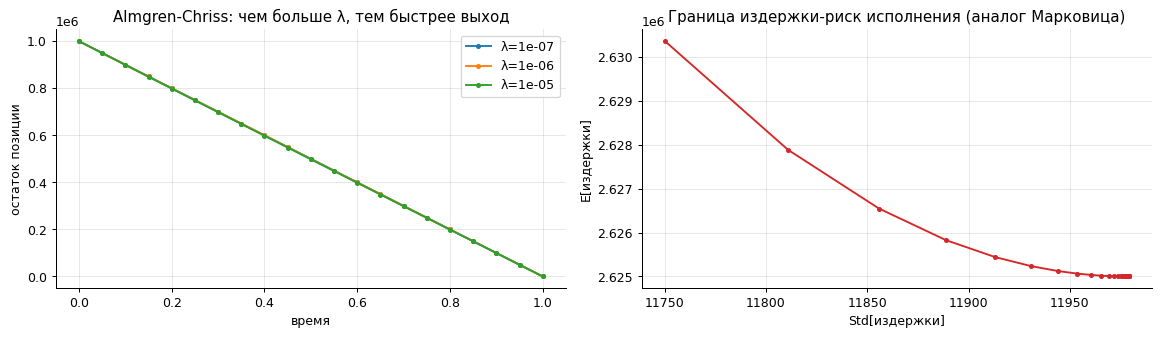

In [42]:
# 4) Almgren-Chriss — оптимальная ликвидация и граница издержки-риск
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for lam in [1e-7, 1e-6, 1e-5]:
    a = liq.AlmgrenChriss(0.02, 2.5e-6, 2.5e-7, lam)
    s = a.schedule(total_shares=1_000_000, horizon=1.0, n_steps=20)
    ax[0].plot(s.times, s.holdings, '-o', ms=3, label=f"λ={lam:.0e}")
ax[0].set_title("Almgren-Chriss: чем больше λ, тем быстрее выход")
ax[0].set_xlabel("время"); ax[0].set_ylabel("остаток позиции"); ax[0].legend()
front = liq.AlmgrenChriss(0.02, 2.5e-6, 2.5e-7).efficient_frontier(
    1_000_000, 1.0, 20, np.logspace(-8, -4, 30))
ax[1].plot(front['Std_cost'], front['E_cost'], '-o', ms=3, c='C3')
ax[1].set_title("Граница издержки-риск исполнения (аналог Марковица)")
ax[1].set_xlabel("Std[издержки]"); ax[1].set_ylabel("E[издержки]")
plt.tight_layout(); plt.show()

## 14. Хвостовая зависимость через копулы

Линейная корреляция плохо описывает «совместный обвал». Сравним эмпирическую нижнюю
хвостовую зависимость с тем, что дают гауссова и t-копулы.

In [43]:
tcop = dep.StudentTCopula.fit(rets_common)
gcop = dep.GaussianCopula.fit(rets_common)
cmp = dep.compare_dependence_models(rets_common, q=0.05)
print(f"t-копула: ν = {tcop.nu:.2f}  (малое => тяжёлые совместные хвосты)")
print(f"Средняя нижняя хвостовая зависимость по 45 парам:")
print(f"  эмпирически : {cmp['empirical_lower_tail'].mean():.3f}")
print(f"  гауссова    : {cmp['gaussian_copula'].mean():.3f}  (всегда 0 — недооценка!)")
print(f"  t-копула    : {cmp.iloc[:, 2].mean():.3f}")

t-копула: ν = 5.17  (малое => тяжёлые совместные хвосты)
Средняя нижняя хвостовая зависимость по 45 парам:
  эмпирически : 0.531
  гауссова    : 0.000  (всегда 0 — недооценка!)
  t-копула    : 0.283


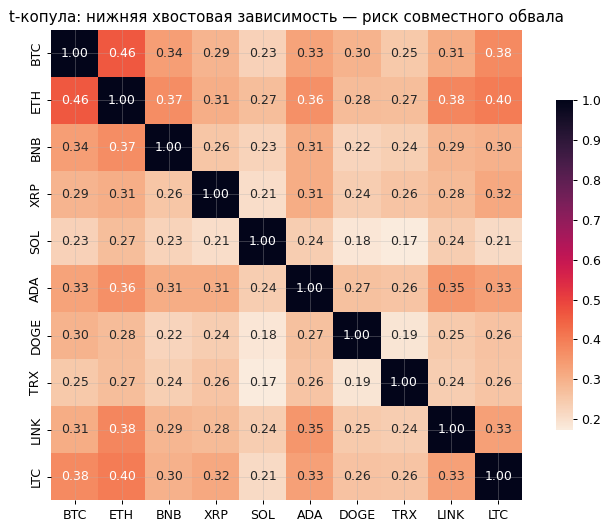

In [44]:
# Тепловая карта хвостовой зависимости (t-копула)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pd.DataFrame(tcop.lower_tail_dependence, index=TOP10_POPULAR,
                         columns=TOP10_POPULAR), annot=True, fmt='.2f',
            cmap='rocket_r', square=True, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title("t-копула: нижняя хвостовая зависимость — риск совместного обвала")
plt.tight_layout(); plt.show()

In [45]:
# Симуляция через копулу даёт более тяжёлый портфельный хвост, чем гауссова
for cop, name in [(gcop, 'Gaussian'), (tcop, 'Student-t')]:
    sim = dep.copula_portfolio_returns(rets_common, w_eq, cop, n_sims=40000)
    v = -np.quantile(sim, 0.01); e = -sim[sim <= np.quantile(sim, 0.025)].mean()
    print(f"{name:10}: VaR99={v:.4f}  ES97.5={e:.4f}")

Gaussian  : VaR99=0.1029  ES97.5=0.1049


Student-t : VaR99=0.1075  ES97.5=0.1129


## 15. Стресс-тесты

Дополним «нормальный» VaR сценариями, которые ломают допущения.

In [46]:
# Реплей: худшие исторические дни для нашего портфеля
hist_sc = stm.historical_scenarios(rets_common, w_eq, horizon=1, top=7)
print("Худшие 1-дневные доходности равновзвешенного портфеля:")
display(hist_sc.round(4))

Худшие 1-дневные доходности равновзвешенного портфеля:


,date,1d_PnL
0,2021-05-19 00:00:00+00:00,-0.3763
1,2021-06-21 00:00:00+00:00,-0.2344
2,2022-11-09 00:00:00+00:00,-0.1912
3,2022-05-09 00:00:00+00:00,-0.1785
4,2022-05-11 00:00:00+00:00,-0.1709
5,2020-12-23 00:00:00+00:00,-0.1661
6,2021-09-07 00:00:00+00:00,-0.1511


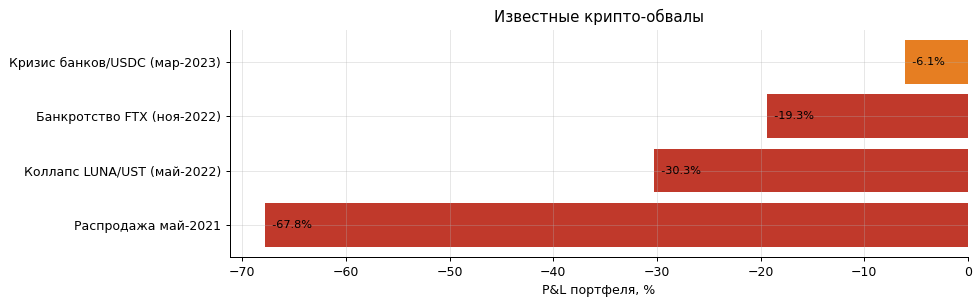

In [47]:
# Именованные крипто-обвалы — там, где у нас есть данные
crashes = stm.named_crypto_crashes(rets_common, w_eq)
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.barh([s.name for s in crashes], [s.pnl*100 for s in crashes],
        color=['#c0392b' if s.pnl < -0.1 else '#e67e22' for s in crashes])
for i, s in enumerate(crashes):
    ax.text(s.pnl*100, i, f"  {s.pnl*100:+.1f}%", va='center', fontsize=9)
ax.set_xlabel("P&L портфеля, %"); ax.set_title("Известные крипто-обвалы")
plt.tight_layout(); plt.show()

Worst-case loss (Breuer, k=3σ): 11.61% за день

Обратный стресс-тест (убыток -50%): k = 12.8σ, вероятность ~ 0.0e+00
Главный драйвер катастрофы: SOL


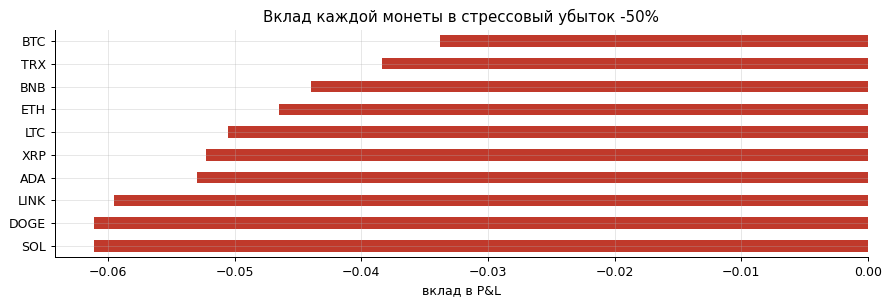

In [48]:
# Worst-case loss (Breuer) и обратный стресс-тест
mu_d, cov_d = pf.mean_cov(rets_common, annualize=False)
wc = stm.worst_case_loss(w_eq, mu_d, cov_d, plausibility_k=3.0)
print(f"Worst-case loss (Breuer, k=3σ): {wc['worst_loss']:.2%} за день")

rev = stm.reverse_stress_test(w_eq, mu_d, cov_d, target_loss=0.50,
                              names=list(TOP10_POPULAR))
print(f"\nОбратный стресс-тест (убыток -50%): k = {rev['required_k']:.1f}σ, "
      f"вероятность ~ {rev['approx_probability']:.1e}")
print(f"Главный драйвер катастрофы: {rev['main_driver']}")
fig, ax = plt.subplots(figsize=(10, 3.5))
rev['loss_contribution'].sort_values().plot.barh(ax=ax,
    color=['#c0392b' if v < 0 else '#27ae60' for v in rev['loss_contribution'].sort_values()])
ax.set_title("Вклад каждой монеты в стрессовый убыток -50%"); ax.set_xlabel("вклад в P&L")
plt.tight_layout(); plt.show()

In [49]:
# Корреляционный стресс: что будет, если все ρ → 0.95
cs = stm.correlation_stress(rets_common, w_eq, target_corr=0.95)
print(f"σ портфеля:   {cs['vol_base']:.2%} -> {cs['vol_stressed']:.2%}  "
      f"(+{cs['vol_increase']:.0%})")
print(f"VaR 99%:       {cs['var_base']:.2%} -> {cs['var_stressed']:.2%}")

σ портфеля:   3.93% -> 5.04%  (+28%)
VaR 99%:       9.15% -> 11.73%


## 16. Декомпозиция риска: кто реально создаёт риск

Веса портфеля и вклад в риск — это разные вещи. Принцип Эйлера раскладывает VaR на
аддитивные вклады активов: их сумма равна VaR портфеля.

,weight,component_VaR,pct_contrib_VaR,pct_contrib_ES
BTC,0.1633,0.0097,0.1065,0.1065
ETH,-0.0000,-0.0000,-0.0000,-0.0000
BNB,0.3523,0.0314,0.3444,0.3444
XRP,-0.0000,-0.0000,-0.0000,-0.0000
SOL,0.1906,0.0229,0.2513,0.2513
ADA,0.0000,0.0000,0.0000,0.0000
DOGE,0.1509,0.0174,0.1903,0.1903
TRX,0.1430,0.0098,0.1075,0.1075
LINK,-0.0000,-0.0000,-0.0000,-0.0000
LTC,-0.0000,-0.0000,-0.0000,-0.0000


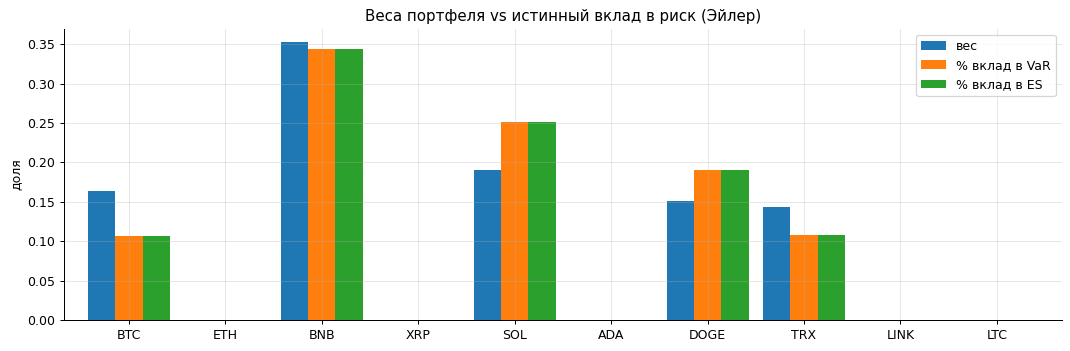

Сумма вкладов в VaR = 1.000 (=1 -> аддитивность)


In [50]:
attr = ve.component_var_es(msr.weights, rets_common, 0.99, 0.975, method='gaussian')
attr_disp = attr[['weight','component_VaR','pct_contrib_VaR','pct_contrib_ES']].round(4)
display(attr_disp)
fig, ax = plt.subplots(figsize=(12, 4))
df_plot = pd.DataFrame({'вес': attr['weight'],
                        '% вклад в VaR': attr['pct_contrib_VaR'],
                        '% вклад в ES':  attr['pct_contrib_ES']}, index=TOP10_POPULAR)
df_plot.plot.bar(ax=ax, width=0.85)
ax.set_title("Веса портфеля vs истинный вклад в риск (Эйлер)")
ax.set_ylabel("доля"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()
print(f"Сумма вкладов в VaR = {attr['pct_contrib_VaR'].sum():.3f} (=1 -> аддитивность)")

## 17. Адаптивный сайзинг и связь с DL

Оценка риска должна *управлять позицией*. Базовая тройка инструментов: volatility
targeting, дробный Келли и drawdown-контроль.

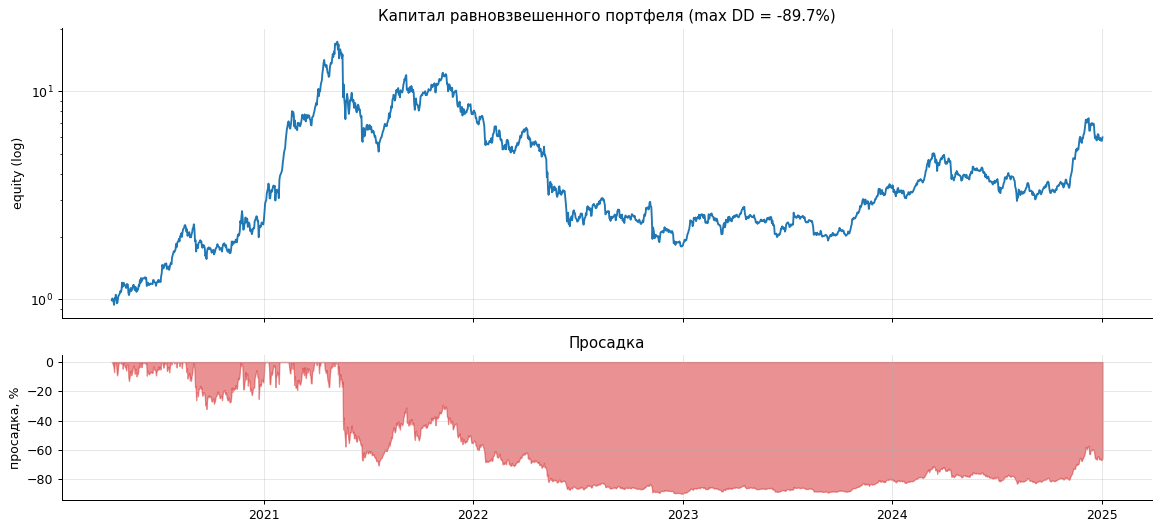

In [51]:
# Кривая капитала и просадки равновзвешенного портфеля
equity = (1 + port).cumprod()
dd = equity / equity.cummax() - 1
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True,
                       gridspec_kw={'height_ratios': [2, 1]})
ax[0].plot(equity.index, equity, c='C0'); ax[0].set_yscale('log')
ax[0].set_title(f"Капитал равновзвешенного портфеля (max DD = {dd.min():.1%})")
ax[0].set_ylabel("equity (log)")
ax[1].fill_between(dd.index, dd*100, 0, color='C3', alpha=0.5)
ax[1].set_ylabel("просадка, %"); ax[1].set_title("Просадка")
plt.tight_layout(); plt.show()

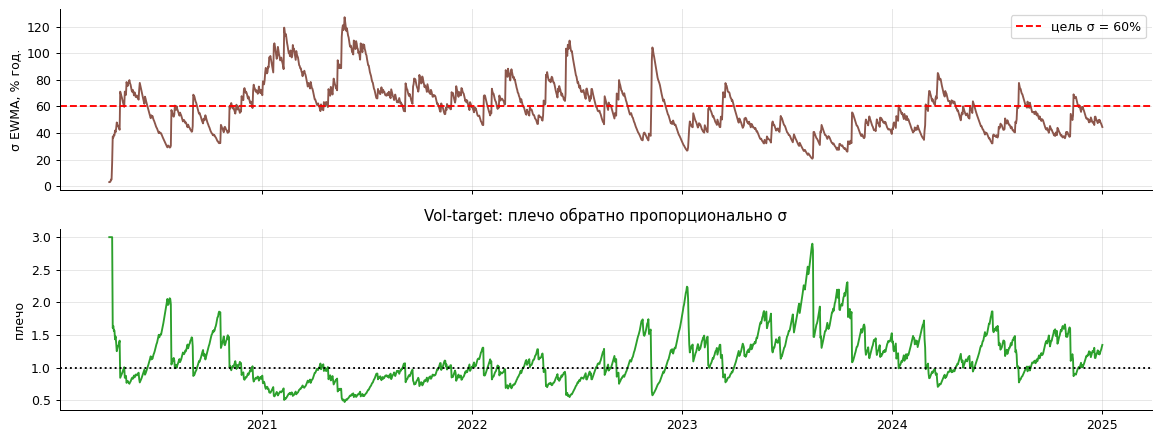

In [52]:
# Volatility targeting: плечо как функция прогнозной σ
ann_vol_series = ewma_sigma_ann.reindex(port.index).ffill()
target = 0.60
lev = (target / ann_vol_series).clip(upper=3.0)
fig, ax = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
ax[0].plot(ann_vol_series.index, ann_vol_series*100, c='C5')
ax[0].axhline(target*100, c='r', ls='--', label=f"цель σ = {target:.0%}")
ax[0].set_ylabel("σ EWMA, % год."); ax[0].legend()
ax[1].plot(lev.index, lev, c='C2'); ax[1].axhline(1.0, c='k', ls=':')
ax[1].set_ylabel("плечо"); ax[1].set_title("Vol-target: плечо обратно пропорционально σ")
plt.tight_layout(); plt.show()

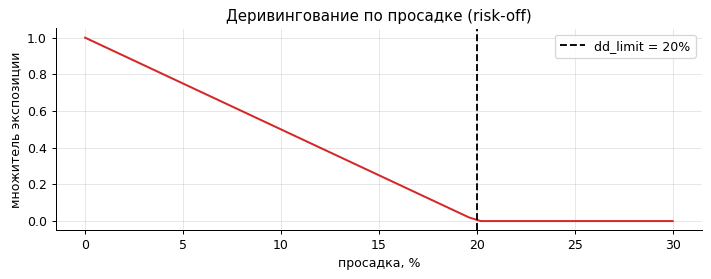

In [53]:
# Drawdown control: множитель экспозиции от просадки
dds = np.linspace(0, 0.30, 50)
mults = [ctl.drawdown_scale(d, dd_limit=0.20) for d in dds]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(dds*100, mults, c='C3', lw=1.6)
ax.axvline(20, c='k', ls='--', label='dd_limit = 20%')
ax.set_xlabel("просадка, %"); ax.set_ylabel("множитель экспозиции")
ax.set_title("Деривингование по просадке (risk-off)"); ax.legend()
plt.tight_layout(); plt.show()

Хук `VolForecaster.set_dl_model(...)` позволяет заменить EWMA/GARCH-прогноз σ на
DL-модель (LSTM/TCN/Transformer) — это и есть связка с глубоким обучением. Сам контур
риска не меняется.

## 18. Всё вместе: `RiskEngine`

Все вышеперечисленные шаги обёрнуты в один объект — оркестратор `RiskEngine`. Так это
выглядит в production-вызове торговой системы.

In [54]:
eng = RiskEngine(RiskConfig(universe=TOP10_POPULAR, capital=1_000_000))
eng.load_data_multi('2015-01-01', '2025-01-01')        # мультиисточник
w = eng.optimal_weights('max_sharpe', 'long_only',
                        cov_method='shrinkage')         # robust Σ
rep = eng.risk_report(weights=w, use_copula=True)       # VaR/ES/LVaR
tail = eng.tail_risk(weights=w)                         # EVT
attr = eng.risk_attribution(weights=w)                  # Эйлер
stress = eng.stress_test(weights=w)                     # стресс-тесты
mr = eng.model_risk(weights=w)                          # модельный риск
print(f"Source: {eng.data_source}")
print(f"Веса (max-Sharpe, shrinkage cov):  {{ {', '.join(f'{k}:{v:.0%}' for k,v in w.items() if v>0.01)} }}")
print(f"Годовая σ портфеля: {rep.annualized_vol:.1%}")
print(f"LVaR (1д, 99%):     {rep.lvar['lvar']:.2%}")
print(f"EVT VaR (POT):       {tail['pot'].var:.2%}")
print(f"Worst-case (k=3σ):   {stress['worst_case']['worst_loss']:.2%}")
print(f"Модельный риск:      разброс {mr['relative_spread']:.0%}, "
      f"зона Базеля {mr['basel_zone']}")

Source: cache:multi_10assets_2015-01-01_2025-01-01.csv
Веса (max-Sharpe, shrinkage cov):  { BTC:15%, BNB:35%, SOL:20%, DOGE:16%, TRX:14% }
Годовая σ портфеля: 75.4%
LVaR (1д, 99%):     11.14%
EVT VaR (POT):       11.42%
Worst-case (k=3σ):   11.61%
Модельный риск:      разброс 32%, зона Базеля GREEN


## 19. Что мы узнали и зачем это всё

**По данным.** Бесплатные источники крипты разрозненны и каждый со своим горизонтом.
Чтобы получить честную историю с 2015 года для всех 10 монет, нужна цепочка источников
с дозаполнением пропусков — что мы и сделали в `MultiSourceCryptoLoader`.

**По доходностям.** У всех монет: тяжёлые хвосты (эксцесс 5-30), сильная кластеризация
волатильности, заметная отрицательная асимметрия. Нормальное распределение здесь
систематически занижает риск. Логично использовать GARCH-семейство с инновациями
Стьюдента, а для далёких хвостов — EVT.

**По корреляциям.** Они *не постоянны*. В кризис ρ подскакивают почти до 1, и
диверсификация исчезает ровно тогда, когда она нужнее всего. DCC-GARCH ловит это,
гауссова копула — нет (у неё нулевая хвостовая зависимость).

**По портфелю.** Shrinkage-оценки ковариации заметно повышают устойчивость весов
out-of-sample. Декомпозиция Эйлера показывает, что главным источником риска часто
становится не самая «толстая» по весу монета, а самая волатильная или хвостовая.

**По ликвидности.** Для HFT-системы это отдельный слой риска: LVaR добавляет к ценовому
VaR компоненту спреда, Almgren-Chriss даёт оптимальное расписание ликвидации, а
Implementation Shortfall раскладывает реальную стоимость исполнения на спред / импакт /
комиссии. Без этого слоя «бумажный» VaR — это не риск, а fiction.

**По управлению.** Volatility targeting, дробный Келли и drawdown-контроль превращают
оценку риска в *размер позиции*. Хук под DL-модель встроен — производственная LSTM/TCN
сюда подключается одной строкой `VolForecaster.set_dl_model(...)`.

### Использованные методы и где они в коде
| Метод | Модуль | Источник теории |
|---|---|---|
| Мультиисточниковый парсер с фолбэком | `data/parsers.py` | — |
| EWMA, GARCH/GJR/EGARCH, range-σ, HAR-RV | `volatility.py` | theory/Volatility |
| VaR/ES: hist, param, CF, EWMA, GARCH, FHS, MC, бутстрэп-горизонт | `var_es.py` | theory/VaR&ES, Time Aggregation |
| Декомпозиция Эйлера (component/marginal/incremental) | `var_es.py` | Tasche |
| EVT (POT/GPD, conditional EVT, Hill) | `evt.py` | theory/EVT (McNeil, Gilli-Kellezi) |
| Бэктестинг VaR/ES (Kupiec, Christoffersen, DQ, Berkowitz, Acerbi-Szekely) | `backtesting.py` | theory/Backtesting ES |
| Метрика модельного риска + зона Базеля | `backtesting.py` | theory/Model Risk |
| Граница, беты, two-fund, Монте-Карло, max-risk | `portfolio.py` | theory/Portfolio Concepts |
| Ledoit-Wolf, const-corr, RMT, DCC-GARCH | `covariance.py` | RMGuide, Volatility |
| LVaR Bangia, market impact, IS, Almgren-Chriss | `liquidity.py` | theory/LVaR & Optimal Execution |
| Копулы Gaussian/Student-t, хвостовая зависимость | `dependence.py` | theory/Copula |
| Стресс-тесты, worst-case, reverse stress | `stress.py` | theory/Stress Testing |
| Vol-target, Kelly, drawdown, DL-хук | `controls.py` | — |
| `RiskEngine` — оркестратор | `engine.py` | — |

> Воспроизводимость: `crypto_risk.config.RANDOM_SEED = 42`. Данные кэшируются в
> `data_cache/multi_10assets_2015-01-01_2025-01-01.csv`.
